<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/Classical%20Models/mfcc_ml_16bit_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Dump

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
numeric = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_numeric.csv"
)

command = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_command.csv"
)

read = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_read.csv"
)

conversation = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_conversation.csv"
)

print("Numeric:", numeric.shape)
print("Command:", command.shape)
print("Read:", read.shape)
print("Conversation:", conversation.shape)

Numeric: (3000, 99)
Command: (3000, 99)
Read: (3000, 99)
Conversation: (3000, 99)


In [ ]:
numeric["speech_type"] = "numeric"
command["speech_type"] = "command"
read["speech_type"] = "read"
conversation["speech_type"] = "conversational"

In [ ]:
df = pd.concat(
    [
        numeric,
        command,
        read,
        conversation
    ],
    ignore_index=True
)

print(df.shape)

print(df["speech_type"].value_counts())

(12000, 100)
speech_type
numeric           3000
command           3000
read              3000
conversational    3000
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()

df["target"] = le.fit_transform(
    df["speech_type"]
)

print(
    dict(
        zip(
            le.classes_,
            range(len(le.classes_))
        )
    )
)

{'command': 0, 'conversational': 1, 'numeric': 2, 'read': 3}


In [ ]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)

y = df["target"]

print("Features Shape:", X.shape)

Features Shape: (12000, 98)


In [ ]:
# First split: 80 train, 20 temp

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Split temp into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 98)
Validation: (1200, 98)
Test: (1200, 98)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

# 96 Features

In [ ]:
xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softmax',

    num_class=4,

    random_state=42,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_acc = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_test_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Validation Accuracy:", xgb_val_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 1.0
Validation Accuracy: 0.9325
Test Accuracy: 0.9316666666666666


In [ ]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.91      0.89      0.90       300
conversational       0.94      0.95      0.95       300
       numeric       1.00      0.99      0.99       300
          read       0.88      0.90      0.89       300

      accuracy                           0.93      1200
     macro avg       0.93      0.93      0.93      1200
  weighted avg       0.93      0.93      0.93      1200



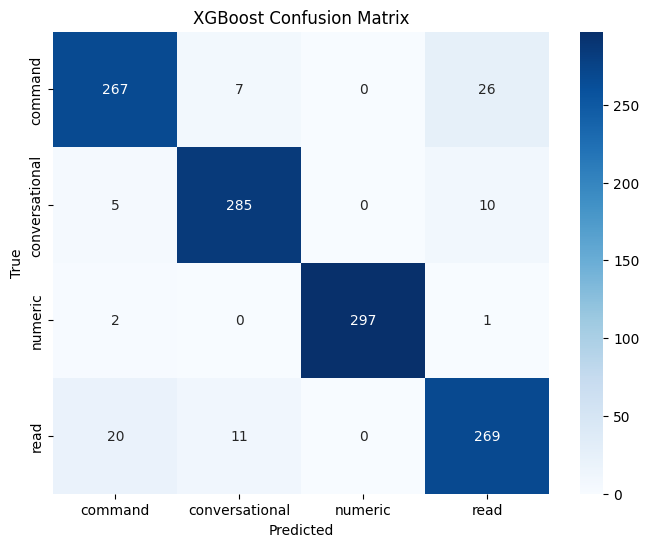

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 89.00%
conversational  : 95.00%
numeric         : 99.00%
read            : 89.67%


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
46,delta_1_mean,0.073298
25,mfcc_6_mean,0.072950
13,std_amdf_min,0.069171
32,mfcc_13_mean,0.047692
33,mfcc_1_std,0.037113
9,max_neg_run,0.033959
12,mean_amdf_min,0.027342
11,std_autocorr_peak,0.026022
21,mfcc_2_mean,0.025255
27,mfcc_8_mean,0.023922


Best Model Evaluation
Accuracy           : 0.9317
Precision (Macro)  : 0.9320
Recall (Macro)     : 0.9317
F1 Score           : 0.9318
ROC-AUC            : 0.9928
Macro F1           : 0.9318
Equal Error Rate   : 0.0393


<Figure size 600x500 with 0 Axes>

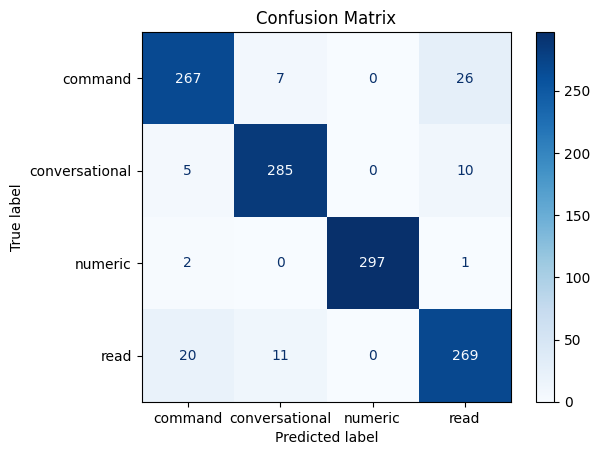

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

# 46 Features

In [ ]:
drop_cols = [
    col for col in df.columns
    if col.startswith("delta_") or col.startswith("delta2_")
]

df = df.drop(columns=drop_cols)

In [ ]:
print("Number of features:", len(df.columns) - 2)   # subtract label and class
print(df.shape)

Number of features: 47
(12000, 49)


In [ ]:
df.columns


Index(['mean_zcr', 'std_zcr', 'min_zcr', 'max_zcr', 'mean_pos_run',
       'std_pos_run', 'max_pos_run', 'mean_neg_run', 'std_neg_run',
       'max_neg_run', 'mean_autocorr_peak', 'std_autocorr_peak',
       'mean_amdf_min', 'std_amdf_min', 'mean_hnr', 'std_hnr',
       'mean_rhythm_change', 'std_rhythm_change', 'active_frame_ratio',
       'longest_active_region', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean',
       'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_6_mean', 'mfcc_7_mean',
       'mfcc_8_mean', 'mfcc_9_mean', 'mfcc_10_mean', 'mfcc_11_mean',
       'mfcc_12_mean', 'mfcc_13_mean', 'mfcc_1_std', 'mfcc_2_std',
       'mfcc_3_std', 'mfcc_4_std', 'mfcc_5_std', 'mfcc_6_std', 'mfcc_7_std',
       'mfcc_8_std', 'mfcc_9_std', 'mfcc_10_std', 'mfcc_11_std', 'mfcc_12_std',
       'mfcc_13_std', 'label', 'speech_type', 'target'],
      dtype='object')

In [ ]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)

y = df["target"]

print("Features Shape:", X.shape)


Features Shape: (12000, 46)


In [ ]:
# First split: 80 train, 20 temp

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Split temp into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 46)
Validation: (1200, 46)
Test: (1200, 46)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

In [ ]:
xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softmax',

    num_class=4,

    random_state=42,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_acc = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_test_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Validation Accuracy:", xgb_val_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 1.0
Validation Accuracy: 0.9291666666666667
Test Accuracy: 0.9258333333333333


Best Model Evaluation
Accuracy           : 0.9258
Precision (Macro)  : 0.9257
Recall (Macro)     : 0.9258
F1 Score           : 0.9257
ROC-AUC            : 0.9913
Macro F1           : 0.9257
Equal Error Rate   : 0.0414


<Figure size 600x500 with 0 Axes>

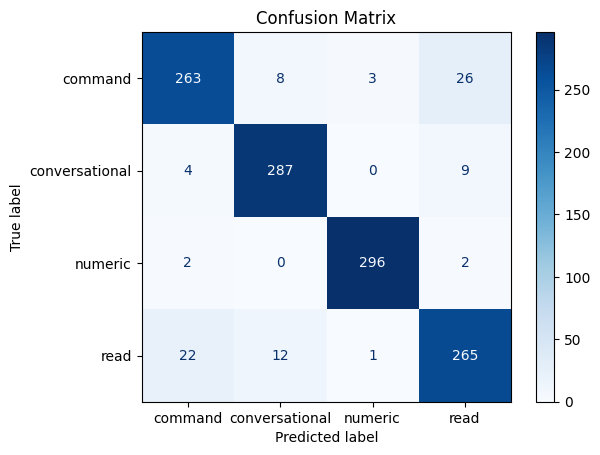

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 87.67%
conversational  : 95.67%
numeric         : 98.67%
read            : 88.33%


# Cross Model Inference-46

In [ ]:
import pandas as pd

# -------------------------
# 16-bit
# -------------------------

numeric16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_numeric.csv"
)

command16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_command.csv"
)

read16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_read.csv"
)

conversation16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_conversation.csv"
)

numeric16["class"] = 0
command16["class"] = 1
read16["class"] = 2
conversation16["class"] = 3

df16 = pd.concat(
    [
        numeric16,
        command16,
        read16,
        conversation16
    ],
    ignore_index=True
)

# -------------------------
# 1-bit
# -------------------------

numeric1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_numeric.csv"
)

command1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_command.csv"
)

read1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_read.csv"
)

conversation1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_conversation.csv"
)

numeric1["class"] = 0
command1["class"] = 1
read1["class"] = 2
conversation1["class"] = 3

df1 = pd.concat(
    [
        numeric1,
        command1,
        read1,
        conversation1
    ],
    ignore_index=True
)

print(df16.shape)
print(df1.shape)

(12000, 100)
(12000, 100)


In [ ]:
print(df16["class"].equals(df1["class"]))
print(df16["label"].equals(df1["label"]))

True
True


In [ ]:
drop_cols = [
    c for c in df1.columns
    if c.startswith("delta_") or c.startswith("delta2_")
]

df1_46 = df1.drop(columns=drop_cols)
df16_46 = df16.drop(columns=drop_cols)

print(df1_46.shape)
print(df16_46.shape)

(12000, 48)
(12000, 48)


In [ ]:
X16 = df16_46.drop(columns=["label", "class"])
y16 = df16_46["class"]

X1 = df1_46.drop(columns=["label", "class"])
y1 = df1_46["class"]

print(X16.shape)
print(X1.shape)

(12000, 46)
(12000, 46)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(df16_46))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y16
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y16.iloc[temp_idx]
)

In [ ]:
X_train = X16.iloc[train_idx]
y_train = y16.iloc[train_idx]

X_test = X1.iloc[test_idx]
y_test = y1.iloc[test_idx]

print(X_train.shape)
print(X_test.shape)

(9600, 46)
(1200, 46)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)

print("="*60)
print("CROSS MODEL INFERENCE")
print("="*60)
print("Training Representation : 16-bit")
print("Testing Representation  : 1-bit")
print()
print("Features :", X_train.shape[1])
print()
print("Accuracy :", round(acc,4))

CROSS MODEL INFERENCE
Training Representation : 16-bit
Testing Representation  : 1-bit

Features : 46

Accuracy : 0.4133


# Cross Model Inference-98

In [ ]:
import pandas as pd

# -------------------------
# 16-bit
# -------------------------

numeric16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_numeric.csv"
)

command16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_command.csv"
)

read16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_read.csv"
)

conversation16 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/16-Bit/features98_16bit_conversation.csv"
)

numeric16["class"] = 0
command16["class"] = 1
read16["class"] = 2
conversation16["class"] = 3

df16 = pd.concat(
    [
        numeric16,
        command16,
        read16,
        conversation16
    ],
    ignore_index=True
)

# -------------------------
# 1-bit
# -------------------------

numeric1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_numeric.csv"
)

command1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_command.csv"
)

read1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_read.csv"
)

conversation1 = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/98features/1-Bit/features98_1bit_conversation.csv"
)

numeric1["class"] = 0
command1["class"] = 1
read1["class"] = 2
conversation1["class"] = 3

df1 = pd.concat(
    [
        numeric1,
        command1,
        read1,
        conversation1
    ],
    ignore_index=True
)

print(df16.shape)
print(df1.shape)

(12000, 100)
(12000, 100)


In [ ]:
X1 = df1.drop(columns=["label","class"])
y1 = df1["class"]

X16 = df16.drop(columns=["label","class"])
y16 = df16["class"]

print(X1.shape)
print(X16.shape)

(12000, 98)
(12000, 98)


In [ ]:
# -------- Train on 16-bit --------

X_train = X16.iloc[train_idx]
y_train = y16.iloc[train_idx]

# -------- Test on 1-bit --------

X_test = X1.iloc[test_idx]
y_test = y1.iloc[test_idx]

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("="*60)
print("98 Feature Cross Model Evaluation")
print("="*60)
print("Train : 16-bit")
print("Test  : 1-bit")
print("Features :", X_train.shape[1])
print("Accuracy :", accuracy_score(y_test, pred))

98 Feature Cross Model Evaluation
Train : 16-bit
Test  : 1-bit
Features : 46
Accuracy : 0.41333333333333333
